In [ ]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.3 MB/s eta 0:00:00


In [ ]:
import transformers
import torch
import evaluate
import pandas as pd
import numpy as np
from datasets import Dataset,interleave_datasets

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
data = Dataset.from_pandas(pd.read_json("/content/drive/MyDrive/Sports_and_Outdoors_5.json",lines=True)[['reviewText','overall']])
data

Mounted at /content/drive


Dataset({
    features: ['reviewText', 'overall'],
    num_rows: 296337
})

In [ ]:
import regex as re
def clean(example):
  example['reviewText'] = re.sub(r'<.*?>',' ',example['reviewText'])
  example['reviewText'] = re.sub(r'http\S+|www\S+|https\S+',' ',example['reviewText'])   #\S non white space character
  example['reviewText'] = re.sub(r'\s+',' ',example['reviewText']).strip()  #\s for white space characters
  return example

data = data.map(clean)

Map:   0%|          | 0/296337 [00:00<?, ? examples/s]

In [ ]:
data['overall'][1]

5

In [ ]:
label_to_sentiment = {}
sentiment_to_label = {}
for i in data.unique('overall'):
  if i==1 or i==2 or i == 3:
    label_to_sentiment[i] = 0
    sentiment_to_label[0] = i
  elif i==4:
    label_to_sentiment[i] = 1
    sentiment_to_label[1] = i
  else:
    label_to_sentiment[i] = 2
    sentiment_to_label[2] = i
print(label_to_sentiment)
print(sentiment_to_label)


{5: 2, 4: 1, 3: 0, 2: 0, 1: 0}
{2: 5, 1: 4, 0: 1}


In [ ]:
def custom_label(x):
  x['overall'] = label_to_sentiment[x['overall']]
  return x
data = data.map(custom_label)

Map:   0%|          | 0/296337 [00:00<?, ? examples/s]

In [ ]:
data.shuffle()[:5]

{'reviewText': ['Works great on my AK. The magnifier also does not give me any problems. I had my doublts on the push buttons but, it works fine. Highly recommended. Plus Vortex has great customer service. I asked about a diffrent mount (Low rise) and they sold it to me cheaper than MSRP plus ate the shipping. They would have sent me one for nothing if I sent the one I had too them but, I did not know which one I wanted. For the record, AK and AKM platform use the low rise',
  'This sight performs as well as my much more expensive GG&G. The only complaint I have is that adjustments take noticeably more effort than with the butter smooth GG&G. I hope it gets a little smoother with use. I did lube the contact surfaces with some CLP and that helped a little.',
  'Seems pretty sturdy so far. My little Cheap S&W; lasted me a little over a year. Lets see how long this one lasts.Chris Olsen',
  "This stealthy little knife is super cool. Every one should own one of these knives. I think the ne

In [ ]:
class_weight = pd.DataFrame(data)['overall'].value_counts()
class_weight

,count
overall,
2,253017
1,24071
0,19249


In [ ]:
#class_weight = torch.tensor([1.0/one,1.0/two,1.0/three],dtype = torch.float)
#print(one,two,three)

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("distilbert/distilbert-base-uncased",use_fast = True) #uses fast tokenization (backed by tokenziers library

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
print(tokenizer.vocab_size)
print(f"Max tokenizer input sequence length: {tokenizer.model_max_length}")
tokenizer.convert_ids_to_tokens(tokenizer("I love you")["input_ids"])

30522
Max tokenizer input sequence length: 512


['[CLS]', 'i', 'love', 'you', '[SEP]']

In [ ]:
def tokenize(line):
  return tokenizer(line['reviewText'],padding = False,truncation = True)  #sentences greater than 512 length will be truncated till 512

tokenized_data = data.map(tokenize,batched=True,batch_size = 10000)
tokenized_data

Map:   0%|          | 0/296337 [00:00<?, ? examples/s]

Dataset({
    features: ['reviewText', 'overall', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 296337
})

In [ ]:
tokenized_data = tokenized_data.train_test_split(train_size=.8)

In [ ]:
tokenized_data

DatasetDict({
    train: Dataset({
        features: ['reviewText', 'overall', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 237069
    })
    test: Dataset({
        features: ['reviewText', 'overall', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 59268
    })
})

In [ ]:
tokenized_data['train']

Dataset({
    features: ['reviewText', 'overall', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 237069
})

**IGNORE BELOW BLOCK IF USING LOSS PENALTY**

In [ ]:
balanced_data = interleave_datasets([tokenized_data['train'].filter(lambda x:x['overall'] == 0),
                                     tokenized_data['train'].filter(lambda x:x['overall'] == 1),
                                     tokenized_data['train'].filter(lambda x:x['overall'] == 2)],probabilities = [0.33,0.33,0.34],
                                     stopping_strategy = 'all_exhausted') #'first_exhausted undersamples majority , all_exhausted oversamples minority

balanced_data.set_format(type = 'torch' , columns = ['input_ids','attention_mask','overall'])


Filter:   0%|          | 0/237069 [00:00<?, ? examples/s]

Filter:   0%|          | 0/237069 [00:00<?, ? examples/s]

Filter:   0%|          | 0/237069 [00:00<?, ? examples/s]

In [ ]:
import pandas as pd

balanced_data.to_pandas()['overall'].value_counts()

KeyError: 'overall'

In [ ]:
from torch.utils.data import DataLoader

tokenized_data['test'].set_format(type = 'torch' , columns = ['input_ids','attention_mask','overall'])

train_loader = DataLoader(balanced_data , shuffle = True , batch_size = 60)
test_loader = DataLoader(tokenized_data['test'],shuffle = True,batch_size = 60)

In [ ]:
from typing import Tuple

acc = evaluate.load('accuracy')
macro_f1 = evaluate.load('f1')
def metrics(a : Tuple[np.array,np.array]):
  pred,label = a[0],a[1]
  if len(pred.shape)>=2:
    pred = np.argmax(pred,axis = 1)

  return {'accuracy':acc.compute(predictions = pred,references = label)['accuracy'],'f1':macro_f1.compute(predictions = pred,references = label, average = 'macro')['f1']}

In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(pretrained_model_name_or_path = "distilbert/distilbert-base-uncased",num_labels = 3)
model

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [ ]:
trainable_parameters = np.sum([i.numel() for i in model.parameters() if i.requires_grad])
total_params = np.sum([i.numel() for i in model.parameters()])
print("Total Trainable Parameters ",trainable_parameters)
print("Total Parameters ",total_params)

Total Trainable Parameters  66955779
Total Parameters  66955779


# Below Results are for Training with Oversampled Data , further below we have data trained with Gradual Unfreeze and weighted penalty.

In [ ]:
from transformers import TrainingArguments

train_args = TrainingArguments(output_dir="/content/drive/MyDrive/sentiment_experiment",
                               learning_rate = 2e-5 ,per_device_train_batch_size = 32 ,
                               per_device_eval_batch_size=32,
                               num_train_epochs = 3,
                               eval_strategy = 'steps' ,
                               eval_steps = 500,
                               save_strategy = 'steps',
                               save_steps = 500,
                               logging_strategy = 'steps' ,
                               logging_steps = 100,
                               fp16 = True,
                               save_total_limit = 3,
                               load_best_model_at_end = True ,
                               metric_for_best_model = "f1",
                               dataloader_num_workers = 4,      # Multi-core data loading
                               dataloader_pin_memory = True,    # Faster CPU -> GPU transfer
                               group_by_length = True,          # It groups reviews of similar lengths together minimizing the amount of "padding" in each batch.
                               gradient_accumulation_steps=4)  # Effective Batch 128 = 4 * 32

In [ ]:
#model(**tokenized_data['train'][0])

In [ ]:
from transformers import Trainer,DataCollatorWithPadding

balanced_data = balanced_data.rename_column("overall","labels")
#balanced_data = balanced_data.map(lambda x: {'labels': x['labels'] - 1})
test_data = tokenized_data['test'].rename_column("overall", "labels")
#test_data = test_data.map(lambda x: {'labels': x['labels'] - 1})

trainer = Trainer(model = model,
                  args = train_args,
                  data_collator = DataCollatorWithPadding(tokenizer = tokenizer),
                  train_dataset = balanced_data,
                  eval_dataset = test_data,
                  compute_metrics = metrics)
trainer.train()

Step,Training Loss,Validation Loss,Accuracy,F1
500,2.724485,0.635404,0.727037,0.679115
1000,2.530511,0.588709,0.749595,0.702239
1500,2.421522,0.586382,0.753155,0.697620
2000,2.312458,0.562133,0.764359,0.711288
2500,2.216529,0.598212,0.738155,0.705468
3000,2.206977,0.587202,0.747267,0.713388
3500,2.092463,0.610281,0.733735,0.705469


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
from transformers import pipeline

pipe = pipeline("sentiment-analysis",model = model,tokenizer=tokenizer,device = 0)


In [ ]:
tokenized_data['test'].set_format(
    type='torch',
    columns=['input_ids', 'attention_mask', 'overall'],
    output_all_columns=True
)

samples = tokenized_data['test'][-5:]['reviewText']
results = pipe(samples,truncation=True,max_length = 512)

for text, res in zip(samples, results):
    print(f"Result: {res['label']} | Text: {text[:50]}...")
print(tokenized_data['test'][-5:]['overall'])

Result: LABEL_2 | Text: Exactly what I hoped for - pretty ordinary but nic...
Result: LABEL_1 | Text: Go ahead and buy this sock.  It is nicely cushione...
Result: LABEL_0 | Text: I gave it a one simply because everyone has been g...
Result: LABEL_0 | Text: Dead on arrival...I waited too long to return. My ...
Result: LABEL_2 | Text: I love these splash guards! I hated always spillin...
tensor([2, 2, 0, 0, 2])


#Custom Training with gradual Unfreeze and Weighted penalty

For DistikBert Model :

1.   The Blocks (0-5): These are the complex Transformer units. They handle the "heavy lifting" of understanding the relationship between words in your Amazon reviews.
2.   The MLP Head: This sits at the very end and consists of the Pre-classifier and the Classifier(specific for our classes). It takes the "summary" vector (CLS token) from the blocks and decides if a review is Class 0, 1, or 2.

When we freeze some layers , we have set requires_grad = False , but when we unfreeze and train , it doesn't start from scratch but from the learned heuristics of pretraining (upstream task) .


Gradual Unfreezing Schedule (Step-Based)

Steps	Layers Unfrozen	Purpose:

I: Warm-up	0 – 500	MLP Head Only	Align the head to your specific 3-class distribution.

II: Deep Dive	501 – 1500	Head + Blocks 4 & 5	Adjust the most abstract semantic features.

III: Full fine Tune	1501+	All Blocks (0-5)	Refine basic grammar and syntax understanding.

In [ ]:
from transformers import TrainerCallback

class CustomCallbackFunc(TrainerCallback):
  def on_step_begin(self,args,state,control,model = None , **kwargs):
    if state.global_step == 0 :

      #print("Training only the classifier Head and Pre-Classifier")
      for i in model.parameters():
        i.requires_grad = False
      for i in model.classifier.parameters():
        i.requires_grad = True
      for i in model.pre_classifier.parameters():
        i.requires_grad = True

    elif state.global_step==501:

      #print("Training transformer blocks 4 and 5 along with all classifier MLPs")
      for j in range(4,6):
        for i in model.distilbert.transformer.layer[j].parameters():
          i.requires_grad = True
    elif state.global_step == 1501:

      #print("Full Fine-Tuning")
      for i in model.parameters():
        i.requires_grad = True

In [ ]:
class_weight = np.array([np.array(class_weight).sum()/(len(class_weight)*i) for i in class_weight])  #total/each_classcount
class_weight = torch.from_numpy(class_weight).float()
class_weight

tensor([0.5248, 1.5242, 2.2802])

In [ ]:
from transformers import Trainer,DataCollatorWithPadding

class WeightedTrainer(Trainer):
  def compute_loss(self,model,inputs,return_outputs=False,num_items_in_batch = None):
    labels = inputs.get("labels")
    outputs = model(**inputs) #Providing the keyword arguments
    logits = outputs.get("logits")

    weights = class_weight.to(self.args.device)

    loss = torch.nn.CrossEntropyLoss(weight=weights)
    loss_output = loss(logits.view(-1,self.model.config.num_labels),labels.view(-1)) #labels.view(-1) for flattening

    return (loss_output,outputs) if return_outputs else loss_output

When you unfreeze layers at Step 501 or 1501, the Optimizer (AdamW) has no "momentum" for those new weights, while the learning rate is likely already high. This can cause a sudden, massive gradient update that "breaks" the pretrained knowledge.
To prevent this, we use a Warmup Schedule.

The Logic: Warmup & Linear Decay

Instead of starting at and staying there, a warmup schedule does this:
Warmup Phase (Steps 0–500): The learning rate starts at 0 and gradually climbs to your maximum (2e-5). This coincides with your "Head Only" training, allowing the MLP to stabilize gently.

Decay Phase (Step 501+): The learning rate slowly decreases. When your new layers unfreeze at Step 501 and 1501, the learning rate is already beginning to lower, making the updates to those sensitive Transformer blocks more cautious and stable.


In [ ]:
import gc
import torch
gc.collect()
torch.cuda.empty_cache()


In [ ]:
from transformers import TrainingArguments

train_args = TrainingArguments(output_dir="/content/drive/MyDrive/sentiment_experiment",
                               learning_rate = 2e-5 ,per_device_train_batch_size = 32 ,
                               per_device_eval_batch_size=32,
                               num_train_epochs = 3,
                               eval_strategy = 'steps' ,
                               eval_steps = 500,
                               save_strategy = 'steps',
                               save_steps = 500,
                               logging_strategy = 'steps' ,
                               logging_steps = 100,
                               save_total_limit = 3,

                               warmup_steps = 500,
                               lr_scheduler_type = 'linear',
                               weight_decay = 0.01,  # Regularization to prevent overfitting

                               fp16 = True,
                               load_best_model_at_end = True ,
                               metric_for_best_model = "f1",

                               disable_tqdm = False,

                               dataloader_num_workers = 2,      # Multi-core data loading
                               dataloader_pin_memory = True,    # Faster CPU -> GPU transfer #Prefetch
                               group_by_length = True,          # It groups reviews of similar lengths together minimizing the amount of "padding" in each batch.

                               gradient_accumulation_steps=4)  # Effective Batch 128 = 4 * 32

1. **Discriminative Learning Rates**:
Standard training uses one learning_rate for everything. This code splits them:

The *Head* (1e-5): The classifier and pre_classifier layers started with random weights and need to move faster to learn how to map 296k reviews into 3 classes.

The *Encoder* (2e-6): The distilbert blocks are the "Brain." They already know English,hence using a much smaller learning rate (5x smaller) here so the model doesn't "forget" its pre-trained knowledge while updating parameters. This prevents Catastrophic Forgetting.

2. **Weight Decay Exclusion**
You’ll notice the no_decay list: ["bias", "LayerNorm.weight"].

Weight decay is a penalty (L2 regularization) that keeps weights small to prevent overfitting. However, applying it to biases or Layer Normalization parameters actually hurts performance because these *parameters need to be free to shift the data distribution*.

The Code  splits the head into two groups—one that gets weight_decay: 0.01 (weights) and one that gets 0.0 (biases/norms).

In [ ]:
new_mapping = {5:2,4:2,3:1,2:0,1:0}

def custom_label(x):
  x['overall'] = new_mapping[x['overall']]
  return x
data = data.map(custom_label)

def tokenize(line):
  return tokenizer(line['reviewText'],padding = False,truncation = True)  #sentences greater than 512 length will be truncated till 512

tokenized_data = data.map(tokenize,batched=True,batch_size = 10000)

tokenized_data = tokenized_data.train_test_split(train_size=.8)

tokenized_data['train']

# After this run , load(accuracy) and AutoModel etc

Map:   0%|          | 0/296337 [00:00<?, ? examples/s]

Map:   0%|          | 0/296337 [00:00<?, ? examples/s]

NameError: name 'tokenizer' is not defined

In [ ]:
def custom_optimizer(model):
  weight_not_decay = ["bias","LayerNorm.weight"]
  grouped_params = [
      {
          "params":[para for id,para in model.named_parameters() if not any(j in id for j in weight_not_decay) and ("classifier" in id or "pre-classifier" in id)],
          "weight_decay": 0.01,
          "lr": 1e-5
      },
      {
          "params":[para for id,para in model.named_parameters() if any (j in id for j in weight_not_decay) and ("classifier" in id or "pre-classifier" in id)],
          "weight_decay": 0.0,
          "lr": 1e-5
      },
      {   "params":[para for id,para in model.named_parameters() if 'distilbert' in id],
          "lr": 2e-6
      }
  ]

  # model.parameters() only returns the tensors. To use the string id (like "classifier" or "distilbert"), use model.named_parameters().
  # (j in id for j in weight_not_decay) is generator object , hence it's always true , so we need iterating codition like any or not any ***

  return torch.optim.AdamW(grouped_params)

In [ ]:
from transformers import DataCollatorWithPadding

tokenized_data = tokenized_data.rename_column("overall","labels")

trainer = WeightedTrainer(model = model,
                  args = train_args,
                  data_collator = DataCollatorWithPadding(tokenizer = tokenizer),
                  train_dataset = tokenized_data['train'],
                  eval_dataset = tokenized_data['test'],
                  compute_metrics = metrics,
                  optimizers = (custom_optimizer(model),None)
                  callbacks = [CustomCallbackFunc()])
trainer.train()

Step,Training Loss,Validation Loss,Accuracy,F1
500,2.470729,0.627956,0.634828,0.258877
1000,1.934690,0.480708,0.719849,0.556536
1500,1.883179,0.466007,0.738459,0.596614
2000,1.767932,0.438718,0.756597,0.636719
2500,1.759781,0.433582,0.771934,0.678523
3000,1.685464,0.420994,0.769572,0.660220
3500,1.687229,0.414271,0.777266,0.682395
4000,1.589243,0.413713,0.780067,0.689670
4500,1.607654,0.412480,0.779206,0.686949
5000,1.566187,0.410673,0.781130,0.688047


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=5559, training_loss=1.8561249341997317, metrics={'train_runtime': 2636.9146, 'train_samples_per_second': 269.712, 'train_steps_per_second': 2.108, 'total_flos': 1.963462735836697e+16, 'train_loss': 1.8561249341997317, 'epoch': 3.0})

In [ ]:
tokenized_data['train']

Dataset({
    features: ['reviewText', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 237069
})

Result: 2 | Text: Nice range bag. I use the pockets on the side for ...
Result: 0 | Text: I would pass on this particular item. There are se...
[2, 0]


'              precision    recall  f1-score   support\n\n           0       0.88      0.58      0.70      8650\n           1       0.58      0.40      0.47     12993\n           2       0.80      0.95      0.87     37625\n\n    accuracy                           0.78     59268\n   macro avg       0.75      0.64      0.68     59268\nweighted avg       0.77      0.78      0.76     59268\n'

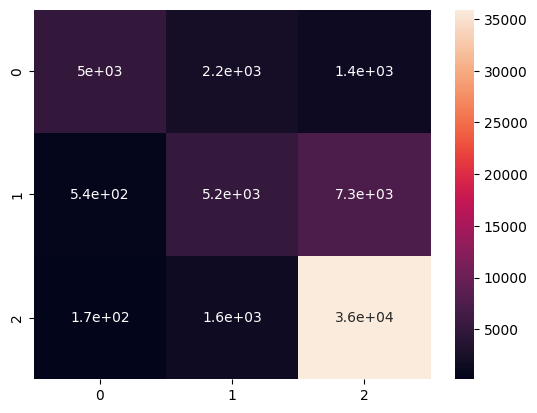

In [ ]:
from transformers import pipeline

pipe = pipeline("sentiment-analysis",model = model,tokenizer=tokenizer,device = 0)



samples = tokenized_data['test'][:2]['reviewText']
results = pipe(samples,truncation=True,max_length = 512)

for text, res in zip(samples, results):
    print(f"Result: {int(res['label'][-1])} | Text: {text[:50]}...")
print(tokenized_data['test'][:2]['labels'])

samples = tokenized_data['test'][:]['reviewText']
results = pipe(samples,truncation=True,max_length = 512,batch_size = 64)

predictions = []
for text, res in zip(samples, results):
    predictions.append(int(res['label'][-1]))

from sklearn.metrics import confusion_matrix,classification_report
import seaborn as sn

y_true = tokenized_data['test'][:]['labels']

cm = confusion_matrix(y_true,predictions)
sn.heatmap(cm,annot=True)

classification_report(y_true,predictions)

In [ ]:
print(classification_report(y_true,predictions))

              precision    recall  f1-score   support

           0       0.88      0.58      0.70      8650
           1       0.58      0.40      0.47     12993
           2       0.80      0.95      0.87     37625

    accuracy                           0.78     59268
   macro avg       0.75      0.64      0.68     59268
weighted avg       0.77      0.78      0.76     59268

